In [1]:
import numpy as np
from math import *

I1 = 0.025
I2 = 0.045
m1 = 1.4
m2 = 1
l1 = 0.3
l2 = 0.33
s1 = 0.11
s2 = 0.16
K = 1 / 0.06
tau = 0.06

a1 = I1 + I2 + m2 * l1 * l1
a2 = m2 * l1 * s2
a3 = I2

Viscous = np.array([[0.05, 0.025], [0.025, 0.05]])


def compute_angles_from_cartesian(x, y, l1=30, l2=33):
    """
    Computes joint angles in radians based on cartesian coordinates.

    Parameters:
        x (float): x-coordinate of the end effector.
        y (float): y-coordinate of the end effector.
        l1 (float): Length of the first link.
        l2 (float): Length of the second link.

    Returns:
        angles (float): Computed angle in radians.
    """
    r_squared = x**2 + y**2

    shoulder_angle = np.arctan2(y, x) - np.arccos(
        (r_squared + l1**2 - l2**2) / (2 * l1 * np.sqrt(r_squared))
    )

    elbow_angle = np.pi - np.arccos((l1**2 + l2**2 - r_squared) / (2 * l1 * l2))
    return shoulder_angle, elbow_angle


def compute_forcefield(theta, omega, coefficient):
    """
    Compute the joint angles acceleration resulting from a lateral
    velocity-dependent forcefield.

    Args:
        theta : current joint angles
        omega : current joint angular velocities
        acc : current joint angular accelerations
        coefficient : Multiplier coefficient on the force field such that yddot = 13 * coeff * xdot

    """
    D = np.array([[0,coefficient],[0,0]])
    Jacobian = np.array([[-33*np.sin(theta[0]+theta[1])-30*np.sin(theta[0]), -33*np.sin(theta[0]+theta[1])],
                            [33*np.cos(theta[0]+theta[1])+30*np.cos(theta[0]), 33*np.cos(theta[0]+theta[1])]])
    
    return Jacobian.T @ D @ Jacobian @ omega 

def get_inertia_matrix(theta2,e0,args):
    nonlinear_inertia = args.get("nonlinear_inertia", True)
    if nonlinear_inertia:
        M = np.array(
            [
                [a1 + 2 * a2 * np.cos(theta2), a3 + a2 * np.cos(theta2)],
                [a3 + a2 * np.cos(theta2), a3],
            ]
        )

        Minv = np.linalg.inv(M)

        dM = np.array(
            [[-2 * a2 * np.sin(theta2), -a2 * np.sin(theta2)], [-a2 * np.sin(theta2), 0]]
        )
    else :
        M = np.array(
            [[a1 + 2 * a2 * cos(e0), a3 + a2 * cos(e0)],
              [a3 + a2 * cos(e0), a3]]
        )

        Minv = np.linalg.inv(M)
        dM = np.zeros((2,2))
    return M,Minv,dM

def get_forces(x, args=None):
    nonlinear_muscle = args.get("nonlinear_muscle", True)
    if nonlinear_muscle:
        A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])
        l0 = np.array([7.32, 3.26, 6.4, 4.26, 5.95, 4.04])
        theta0 = np.array(
            [
                [
                    2 * pi / 360 * 15,
                    2 * pi / 360 * 4.88,
                    0,
                    0,
                    2 * pi / 360 * 4.5,
                    2 * pi / 360 * 2.12,
                ],
                [
                    0,
                    0,
                    2 * pi / 360 * 80.86,
                    2 * pi / 360 * 109.32,
                    2 * pi / 360 * 92.96,
                    2 * pi / 360 * 91.52,
                ],
            ]
        )
        l = 1 + A[0] * (theta0[0] - x[0]) / l0 + A[1] * (theta0[1] - x[1]) / l0
        dldts = -A[0] / l0
        dldte = -A[1] / l0

        v = A[0] * (-x[2]) / l0 + A[1] * (-x[3]) / l0
        dvdos = -A[0] / l0
        dvdoe = -A[1] / l0
        fl = np.exp(np.abs((l**1.55 - 1) / 0.81))

        dfldl = (
            np.exp(np.abs((l**1.55 - 1) / 0.81))
            * np.sign((l**1.55 - 1) / 0.81)
            * (1.55 * l**0.55 / 0.81)
        )
        fv = np.where(
            v <= 0,
            (-7.39 - v) / (-7.39 + (-3.21 + 4.17) * v),
            (0.62 - (-3.12 + 4.21 * l - 2.67 * l**2) * v) / (0.62 + v),
        )
        dfvdl = np.where(v <= 0, 0, v * (-4.21 + 5.34 * l) / (0.62 + v))

        dfvdv = np.where(
            v <= 0,
            7.39 * (1 + 0.96) / (-7.39 + 0.96 * v) ** 2,
            -0.62 * (-3.12 + 4.21 * l - 2.67 * l**2 + 1) / (0.62 + v) ** 2,
        )

        dfldts = dfldl * dldts
        dfldte = dfldl * dldte
        dfvdts = dfvdl * dldts
        dfvdte = dfvdl * dldte
        dfvdos = dfvdv * dvdos
        dfvdoe = dfvdv * dvdoe
    else : 
        fl,fv = np.ones(6),np.ones(6) 
        dfldts,dfldte,dfvdts,dfvdte,dfvdos,dfvdoe = np.zeros(6),np.zeros(6),np.zeros(6),np.zeros(6),np.zeros(6),np.zeros(6)
    
    return fl, fv, dfldts, dfldte, dfvdts, dfvdte, dfvdos, dfvdoe

def get_coriolis(x,args=None):
    nonlinear_coriolis = args.get("nonlinear_coriolis", True)
    if nonlinear_coriolis:
        theta1, theta2, dtheta1, dtheta2 = x[:4]
        C = np.array(
            [
                -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.sin(theta2),
                dtheta1**2 * a2 * np.sin(theta2),
            ]
        )

        dCdte = np.array(
            [
                -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.cos(theta2),
                dtheta1**2 * a2 * np.cos(theta2),
            ]
        )
        dCdos = np.array(
            [-dtheta2 * 2 * a2 * np.sin(theta2), 2 * dtheta1 * a2 * np.sin(theta2)]
        )
        dCdoe = np.array([(-2 * dtheta1 - 2 * dtheta2) * a2 * np.sin(theta2), 0])
    else:
        C = np.array([0,0])
        dCdte = np.array(
        [0, 0]
        )
        dCdos = np.array(
            [0, 0]
        )
        dCdoe = np.array(
            [0, 0]
        )
    return C,dCdte,dCdos,dCdoe
def get_linearized_dynamics(x, u, x0, args=None):
    """
    Parameters :
        - x : the state of the system
        - alpha : the body tilt

    return :
        The Jacobian Matrix of the dynamic of the system around the state x
    """

    theta1, theta2, dtheta1, dtheta2 = x[:4]
    C,dCdte,dCdos,dCdoe = get_coriolis(x,args=args)

    M,Minv,dM = get_inertia_matrix(theta2,x0[1],args)

    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    # Compute acceleration dependencies
    dtheta = np.array([dtheta1, dtheta2])
    fl, fv, dfldts, dfldte, dfvdts, dfvdte, dfvdos, dfvdoe = get_forces(x, args=args)
    d_accel_theta1 = Minv @ (A @ (u * (dfldts * fv + fl * dfvdts)))
    d_accel_dtheta1 = Minv @ (
        A @ (u * dfvdos * fl) - dCdos - Viscous @ np.array([1, 0])
    )
    d_accel_theta2 = -Minv @ (
        dM @ Minv @ (A @ (u * fl * fv) - C - Viscous @ dtheta)
    ) + Minv @ (A @ (u * (dfldte * fv + fl * dfvdte)) - dCdte)
    d_accel_dtheta2 = Minv @ (
        A @ (u * dfvdoe * fl) - dCdoe - Viscous @ np.array([0, 1])
    )

    # Construct the Jacobian matrix
    A = np.zeros((4, 4))

    A[0, 2] = 1
    A[1, 3] = 1

    # Acceleration contributions
    A[2, 0] = d_accel_theta1[0]
    A[2, 2] = d_accel_dtheta1[0]
    A[2, 1] = d_accel_theta2[0]
    A[2, 3] = d_accel_dtheta2[0]

    A[3, 0] = d_accel_theta1[1]
    A[3, 2] = d_accel_dtheta1[1]
    A[3, 1] = d_accel_theta2[1]
    A[3, 3] = d_accel_dtheta2[1]

    return A


def f(x, u,x0, F=0, args=None):
    C = get_coriolis(x,args=args)[0]

    M,Minv,dM = get_inertia_matrix(x[1],x0[1],args)
    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    fl, fv = get_forces(x, args=args)[:2]
    theta = Minv @ (A @ (u * fl * fv) - Viscous @ x[2:4] - C + F)

    return np.array([[x[2], x[3], theta[0], theta[1]]])


def fx(x, u, x0, args=None):
    return get_linearized_dynamics(x, u, x0, args)


def fu(x, u, x0, args=None):
    M,Minv,dM = get_inertia_matrix(x[1],x0[1],args)
    A = np.array([[2, -2, 0, 0, 1.5, -2], [0, 0, 2, -2, 2, -1.5]])

    fl, fv = get_forces(x, args=args)[:2]
    sol = np.zeros((4, 6))
    for i in range(6):
        du = np.zeros(6)
        du[i] = 1
        sol[2:, i] = Minv @ (A @ (du * fl * fv))
    return sol


def l(x, u, r1, xtarg=0, w1=0, w2=0):
    return r1 * np.sum(u**2) / 2


def lx(x, u, xtarg=0, w1=0, w2=0):
    return np.zeros(4)


def lu(x, u, r1):
    return r1 * u


def lxx(w1=0, w2=0):
    return np.zeros((4, 4))


def luu(x, u, r1):
    return np.diag(np.ones(len(u))) * r1


def h(x, w1, w2, xtarg):
    return w1 / 2 * ((x[0] - xtarg[0]) ** 2 + (x[1] - xtarg[1]) ** 2) + w2 / 2 * (
        x[2] ** 2 + x[3] ** 2
    )


def hx(x, w1, w2, xtarg):
    return np.array(
        [w1 * (x[0] - xtarg[0]), w1 * (x[1] - xtarg[1]), w2 * x[2], w2 * x[3]]
    )


def hxx(x, w1, w2):
    return np.diag([w1, w1, w2, w2])


def Kalman(Omega_measure, Omega_sens, A, sigma, H):
    K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
    sigma = Omega_sens + (A - K @ H) @ sigma @ A.T
    return K, sigma


def step1(x0, u, Duration,args):
    K = np.shape(u)[0] + 1
    dt = Duration / (K)
    newx = np.zeros((K, len(x0)))
    newx[0] = np.copy(x0)

    for i in range(K - 1):
        newx[i + 1] = newx[i] + dt * f(newx[i], u[i], newx[0],args=args)

    return newx


def step2(x, u, Duration, w1, w2, r1, xtarg,args):
    K = np.shape(u)[0] + 1
    dt = Duration / K
    n, m = len(x[0]), len(u[0])

    A, B = np.zeros((K - 1, n, n)), np.zeros((K - 1, n, m))
    q, qbold = np.zeros(K), np.zeros((K, n))
    r, Q, R = np.zeros((K - 1, m)), np.zeros((K, n, n)), np.zeros((K - 1, m, m))

    for i in range(K - 1):
        A[i] = np.identity(n) + dt * fx(x[i], u[i], x[0], args=args)
        B[i] = dt * fu(x[i], u[i], x[0], args=args)
        q[i] = dt * l(x[i], u[i], r1, xtarg, w1, w2)
        qbold[i] = dt * lx(x[i], u[i], xtarg, w1, w2)
        r[i] = dt * lu(x[i], u[i], r1)
        Q[i] = dt * lxx(w1, w2)
        R[i] = dt * luu(x[i], u[i], r1)

    q[-1], qbold[-1], Q[-1] = (
        h(x[-1], w1, w2, xtarg),
        hx(x[-1], w1, w2, xtarg),
        hxx(x[-1], w1, w2),
    )
    return A, B, q, qbold, r, Q, R


def step3(A, B, C, cbold, q, qbold, r, Q, R, eps):
    K = A.shape[0] + 1
    n, m = np.shape(B[0])
    S = np.zeros((K, n, n))
    s = np.zeros(K)
    sbold = np.zeros((K, n))
    l = np.zeros((K - 1, m))
    L = np.zeros((K - 1, m, n))

    S[-1] = Q[-1]
    s[-1] = q[-1]
    sbold[-1] = qbold[-1]

    for k in np.arange(K - 2, -1, -1):
        temp1, temp2, temp3 = 0, 0, 0

        for i in range(m):
            temp1 += C[k, i, :, :].T @ S[k + 1] @ cbold[k, i, :]
            temp2 += C[k, i, :, :].T @ S[k + 1] @ C[k, i, :, :]
            temp3 += cbold[k, i, :].T @ S[k + 1] @ cbold[k, i, :]

        gbold = r[k] + B[k].T @ sbold[k + 1] + temp1
        G = B[k].T @ S[k + 1] @ A[k]
        H = R[k] + B[k].T @ S[k + 1] @ B[k] + temp2

        eigenvalues, eigenvectors = np.linalg.eig(H)
        V = np.diag(eigenvalues)

        for i in range(V.shape[0]):
            if V[i, i] < (eps):
                print("H matrix poorly defined")
                V[i, i] = eps
            V[i, i] = 1 / V[i, i]
        Hinv = eigenvectors @ V @ np.linalg.inv(eigenvectors)

        S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
        sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
        s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold

        l[k] = -Hinv @ gbold
        L[k] = -Hinv @ G

    return l, L


def step4(l, L, K, A, B):
    m, n = L[0].shape
    x = np.zeros(n)
    u_incr = np.zeros((K - 1, m))

    for k in range(K - 1):
        u_incr[k] = l[k] + L[k] @ x
        x = A[k] @ x + B[k] @ u_incr[k]

    return u_incr


def step5(
    x0,
    l,
    L,
    Duration,
    Noise,
    A,
    B,
    Num_steps,
    bestu,
    kdelay,
    motornoise_variance,
    FF,
    ff_power,
    FFside, args=None
):
    dt = Duration / (Num_steps)
    Num_Var = len(x0)

    x0 = np.tile(x0, kdelay + 1)
    xref = np.zeros((Num_steps, Num_Var * (kdelay + 1)))
    xref[0] = np.copy(x0)
    newx = np.zeros((Num_steps, Num_Var * (kdelay + 1)))
    newx[0] = np.copy(x0)
    xhat = np.zeros((Num_steps, Num_Var * (kdelay + 1)))

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    Omega_measure = np.diag(np.ones(4)) * 1e-4
    F = 0
    for i in range(Num_steps - 1):
        F = (
            compute_forcefield(newx[i, 0:2], newx[i, 2:4], ff_power)
            if FF == True
            else np.array([0, 0])
        )
        if FFside == "Left": F*= -1
        Extended_A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
        Extended_A[:Num_Var, :Num_Var] = A[i]
        Extended_A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)
        Extended_B = np.zeros(((kdelay + 1) * Num_Var, 6))
        Extended_B[:Num_Var] = B[i]

        deltau = l[i] + L[i] @ xhat[i, :Num_Var]
        u = bestu[i] + deltau

        Omega_sens = np.zeros((len(x0), len(x0)))
        for idx in [2, 3]:
            Omega_sens[idx, idx] = motornoise_variance
        K, sigma = Kalman(Omega_measure, Omega_sens, Extended_A, sigma, H)

        passed_newx = np.copy(newx[i, :-Num_Var])
        newx[i + 1, :Num_Var] = newx[i, :Num_Var] + dt * f(newx[i, :Num_Var], u, newx[0, :Num_Var], F, args=args)
        newx[i + 1, Num_Var:] = passed_newx

        passed_xref = np.copy(xref[i, :-Num_Var])
        xref[i + 1, :Num_Var] = xref[i, :Num_Var] + dt * f(xref[i, :Num_Var], bestu[i], xref[0, :Num_Var], F=0, args=args)
        xref[i + 1, Num_Var:] = passed_xref

        if Noise:
            newx[i + 1, 2:4] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        y = H @ (newx[i] - xref[i])
        if Noise:
            y += np.random.normal(0, 1e-2, len(y))

        xhat[i + 1] = (Extended_A @ xhat[i] + Extended_B @ deltau) + K @ (
            y - H @ xhat[i]
        )
    return newx[:, :Num_Var]


def simulate_ILQG(
    Duration=0.5,
    w1=1e3,
    w2=1,
    r1=1e-4,
    targets=[0, 50],
    start=[0, 30],
    K=120,
    Noise=False,
    delay=0,
    eps=1e-4,
    motornoise_variance=1e-3,
    print_iterations=True,
    FF=False,
    ff_power=0.3,
    FFside = "Right",
    args={}
):
    """
    Parameters :
        - Duration : Movement Duration in sec
        - w1,w2,r1 : Weight of the costs function associated to distance penalty  to the target, end velocity, and motor costs respectively
        - targets : Position of the target in cartesian coordinates
        - k : Number of iterations
        - start : Starting position of the hand
        - plot : Boolean, True ==> plotting enabled
        - Noise : Boolean, True ==> Noise Activated in the simulation
        - Delay : Sensory Delay in sec
        - motornoise_variance : Variance of the motor noise
        - alpha : Body Tilt in radiant

    return :
        - X,Y : Cartesian coordinates of the hand trajectory
        - u : Input command
        - x : Vector state of the trajectory
    """

    obj1, obj2 = compute_angles_from_cartesian(targets[0], targets[1])
    st1, st2 = compute_angles_from_cartesian(start[0], start[1])

    x0 = np.array([st1, st2, 0, 0])
    m, n = 6, 4
    u = np.zeros((K - 1, m))
    dt = Duration / K
    kdelay = int(delay / dt)

    cbold = np.zeros((K - 1, m, n))
    C = np.zeros((K - 1, m, n, m))
    for i in range(K - 1):
        for j in range(2):
            cbold[i, j, 2 + j] = sqrt(motornoise_variance)

    u_incr = np.ones(u.shape) * np.inf

    for iterate in range(300):
        x = step1(
            x0, u, Duration, args
        )  # Forward step computing the sequence of state trajectory given a sequence of input u
        X = np.cos(x[:, 0] + x[:, 1]) * 33 + np.cos(x[:, 0]) * 30
        Y = np.sin(x[:, 0] + x[:, 1]) * 33 + np.sin(x[:, 0]) * 30

        if (
            np.max(np.abs(u_incr)) < 1e-14
        ):  # If the trajectory improvement is small enough, stop the iteration and perform a full simulation with feedback and potential noise
            x = step5(
                x0,
                l,
                L,
                Duration,
                Noise,
                A,
                B,
                K,
                u - u_incr,
                kdelay,
                motornoise_variance,
                FF,
                ff_power,
                FFside,
                args
            )
            X = np.cos(x[:, 0] + x[:, 1]) * 33 + np.cos(x[:, 0]) * 30
            Y = np.sin(x[:, 0] + x[:, 1]) * 33 + np.sin(x[:, 0]) * 30
            if print_iterations:
                print("Solution found at iteration ", iterate)
            break

        A, B, q, qbold, r, Q, R = step2(
            x, u, Duration, w1, w2, r1, np.array([obj1, obj2]), args
        )  # Compute the Linearizations of the dynamic
        l, L = step3(
            A, B, C, cbold, q, qbold, r, Q, R, eps
        )  # Compute the control gains improvement (feedforward and feedback)
        u_incr = step4(l, L, K, A, B)  # Compute the command sequence improvement
        u += u_incr  # Improves the command sequence
    return X, Y, x, u

In [2]:
from matplotlib import pyplot as plt

MN = 1e-3
WP = 100
WV = .05
WR = .1


def Cost_function(x,u,w1 = 100,w2 = .05,r = .1,tg = [0,0] ):
    target1,target2 = compute_angles_from_cartesian(tg[0],tg[1])
    thetas,thetae,omegas,omegae = x[-1,:4]
    
    return w1*(thetas-target1)**2 + w1*(thetae-target2)**2 + w2*(omegas**2+omegae**2)+ np.sum(u*u) * r * 0.01

def Compute_Cartesian_Speed(X, Y, dt):
    V = np.zeros(X.shape)
    Vx = np.diff(X) / dt
    Vy = np.diff(Y) / dt
    V[1:] = np.sqrt(Vx * Vx + Vy * Vy)
    return V


def delete_axis(ax, sides=["left", "right", "bottom", "top"]):
    for side in sides:
        ax.spines[side].set_visible(False)


def delete_ticks(ax):
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")


def run_ILQG_simulation(FFPOW=0.3, MovementTime=0.5,st = [0,40],tg = [0,60],params={},NUM_SIM=1,title = ""):    
    NumIteration = int(MovementTime * 100)
    Time = np.linspace(0,MovementTime*1000,NumIteration)

    fig,ax = plt.subplots(3,figsize = (6,10))
    ax[0].set_title(title,fontsize = 16)
    Cost_value = np.zeros((NUM_SIM))
    Angular_Speed = np.zeros((NUM_SIM,2,NumIteration))

    colors = ["#009E73","#0072B2","#E69F00"]
    
    for i in range(NUM_SIM):
        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, args=params)
        if i <= 10: 
            ax[0].plot(xILQG,yILQG, color=colors[0], linewidth=.6,linestyle = "--")
        Angular_Speed[i] = zilqg[:,2:4].T

            
        Cost_value[i]=Cost_function(zilqg,uILQG,tg = tg)

        if i <= 10:
            xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  False)

            ax[0].plot(xILQG,yILQG, color="grey", linewidth=.6,linestyle = "-.")


    mean_vel = np.mean(Angular_Speed[:,0],axis = 0)*180/pi
    std_vel = np.std(Angular_Speed[:,0],axis = 0)*180/pi
    # Pot mean line
    ax[2].plot(Time, mean_vel, color="green")
    # Pot standard deviation band
    ax[2].fill_between(Time, mean_vel - std_vel, mean_vel + std_vel, color="green", alpha=0.3)
    mean_vel = np.mean(Angular_Speed[:,1],axis = 0)*180/pi
    std_vel = np.std(Angular_Speed[:,1],axis = 0)*180/pi
    # Pot mean line
    ax[2].plot(Time, mean_vel, color="green",linestyle = "--")
    #ax[2,i].set_ylim(-4,3)
    # Pot standard deviation band
    ax[2].fill_between(Time, mean_vel - std_vel, mean_vel + std_vel, color="green", alpha=0.3)
    delete_axis(ax[2],sides = ["top","right"])
    ax[2].set_xlabel("Movement Duration [ms]" , fontsize = 15)
    ax[2].set_xticks([0,100,200,300,400,500],labels = [0,100,200,300,400,500],fontsize = 14)
    ax[2].set_ylabel("Angular Velocity [deg/sec]" , fontsize = 15)
    ax[2].set_yticks([-180,-90,0,90,180],labels = [-180,-90,0,90,180],fontsize = 14)
    ax[1].set_yscale('log') 


    box = ax[1].boxplot(Cost_value, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)


    ax[1].set_ylim(.01,100)
    ax[0].set_aspect("equal")
    ax[0].set_yticks([])
    ax[0].set_xticks([])
    ax[1].set_xticks([])
    delete_axis(ax[0])
    delete_axis(ax[1])
        #ax[1,i].set_xticklabels([legend[i]],fontsize = 15)
    for i in range(1,3):
        ax[1].set_yticks([])

    ax[1].set_yticks([.01,.01,.1,1,10,100])
    ax[1].tick_params(axis='y', labelsize=14)
    ax[1].set_ylabel("Movement Cost",fontsize = 15)
    for i in range(1): 
        circle = plt.Circle((0+20*i,60), 1, edgecolor='grey', facecolor='grey', linewidth=3)

    # Add square to plot
        ax[0].add_patch(circle)
        
        #ax[0,i].scatter(tg[0],tg[1],marker = "s",s = 500,color = "grey")
    plt.show()

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


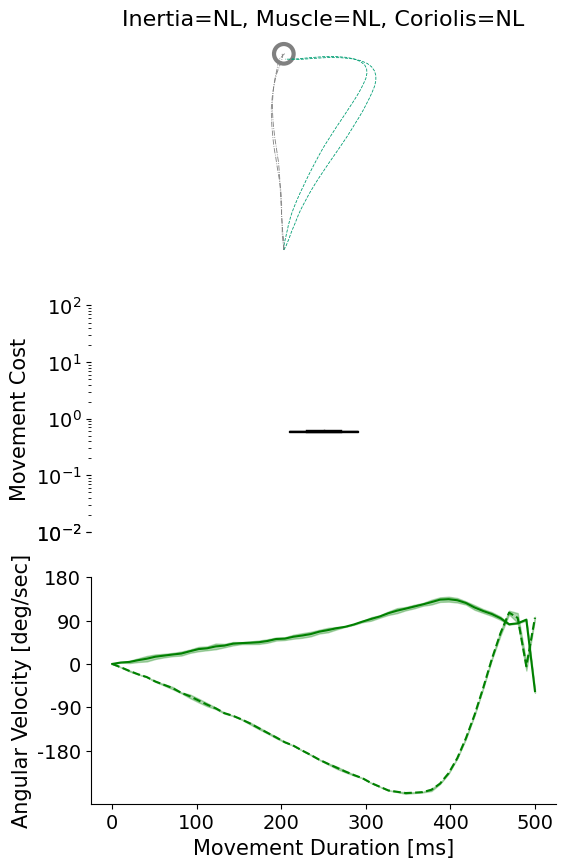

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


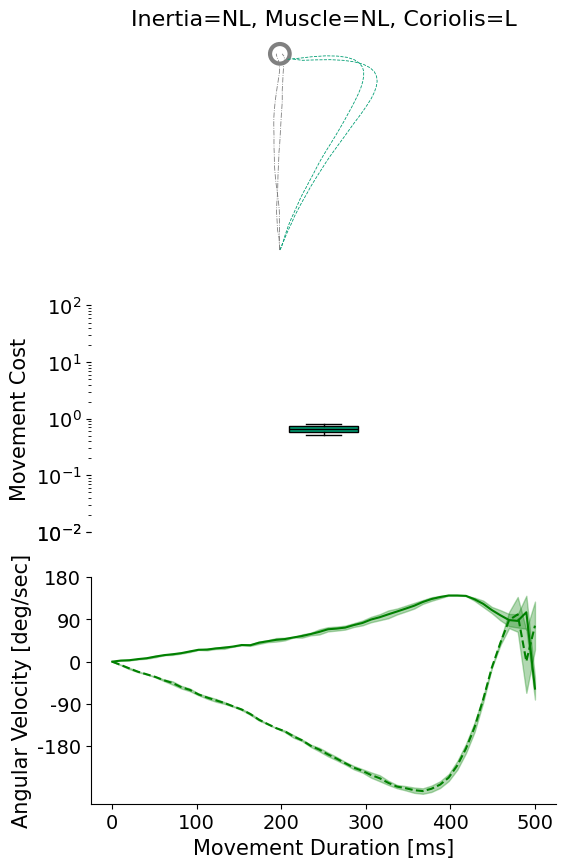

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


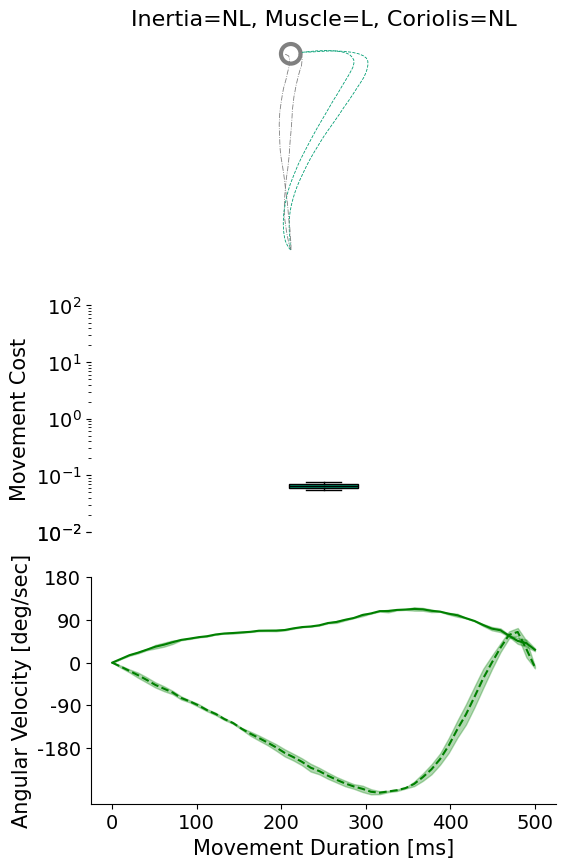

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


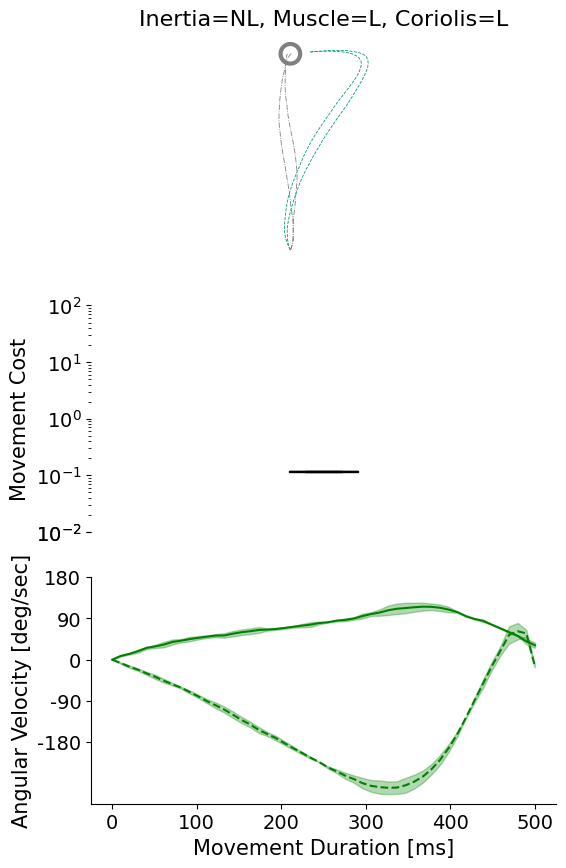

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


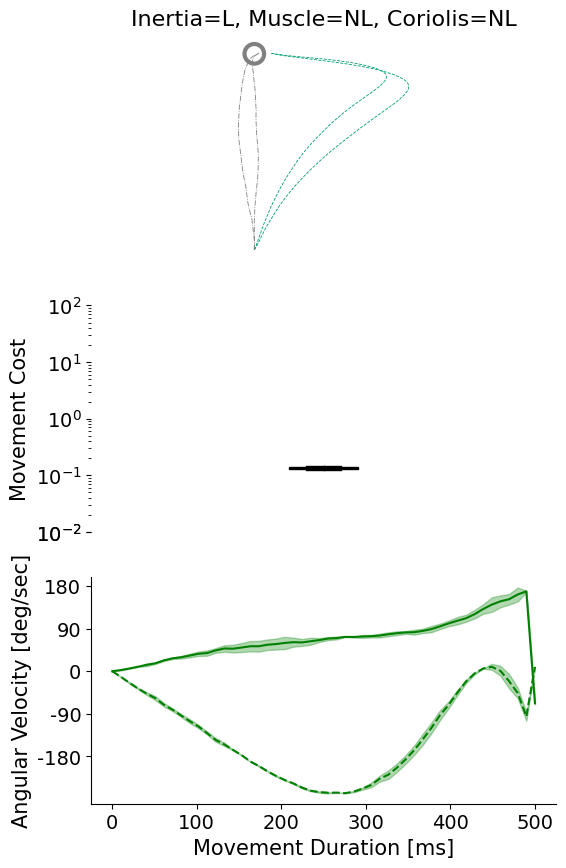

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


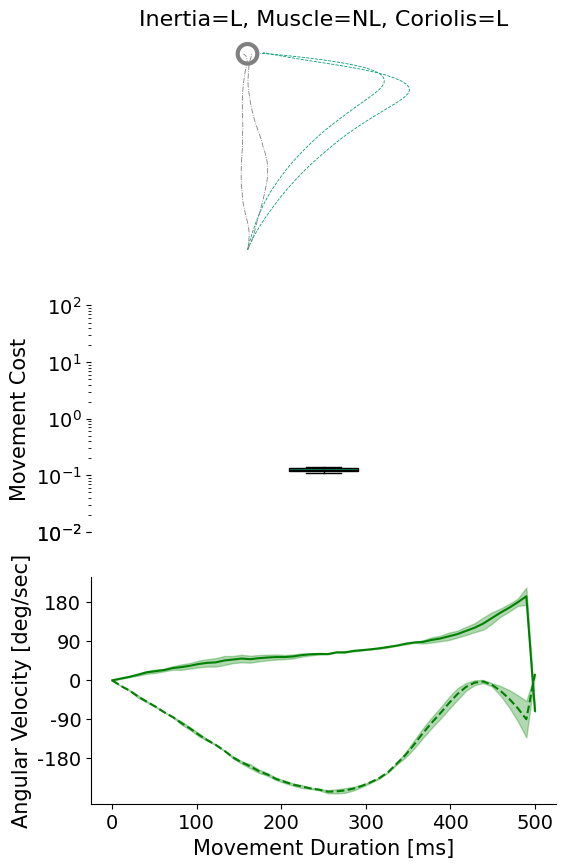

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


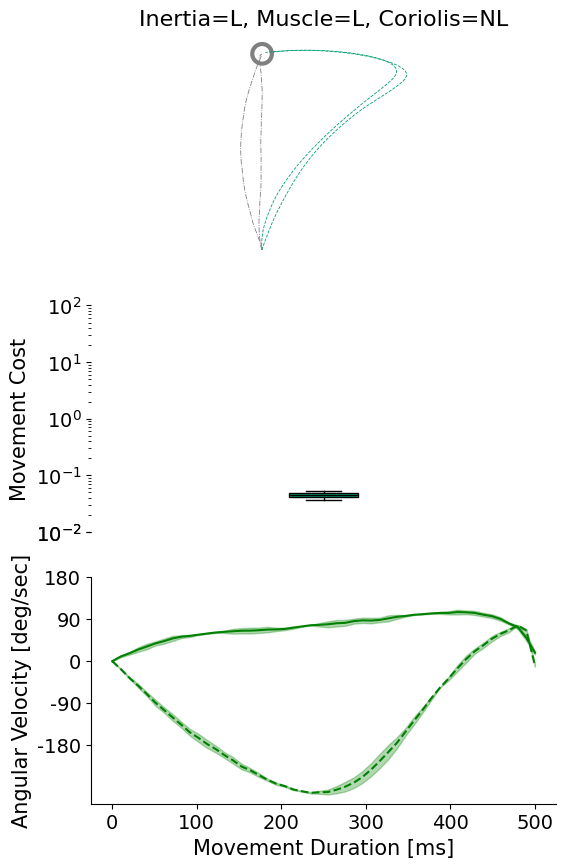

C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:365: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:366: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:367: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:369: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_4020\3169095852.py:370: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


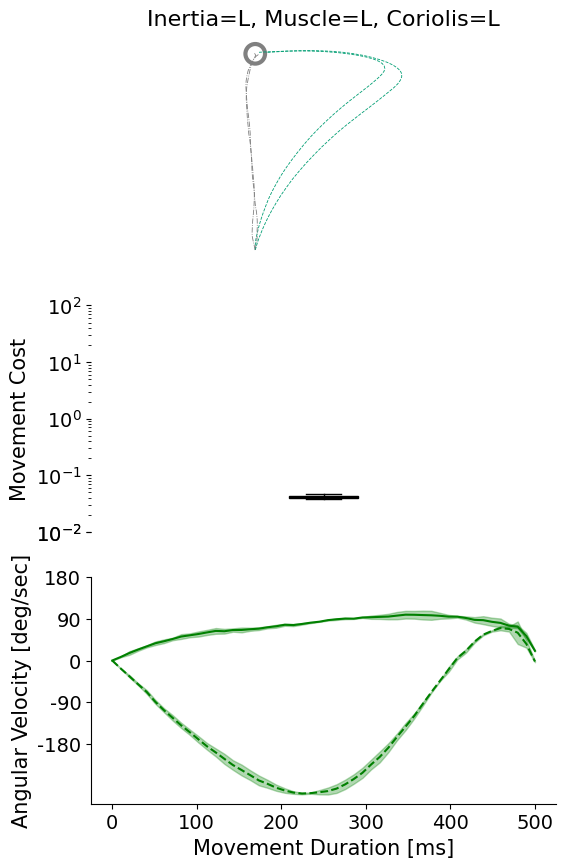

In [58]:
from itertools import product

common_kwargs = dict(
    FFPOW=4e-4,
    MovementTime=0.5,
    st=[0, 40],
    tg=[0, 60],
    NUM_SIM=2,
)

for inertia, muscle, coriolis in product([True, False], repeat=3):
    params = {
        "nonlinear_inertia": inertia,
        "nonlinear_muscle": muscle,
        "nonlinear_coriolis": coriolis,
    }
    title = (
        f"Inertia={'NL' if inertia else 'L'}, "
        f"Muscle={'NL' if muscle else 'L'}, "
        f"Coriolis={'NL' if coriolis else 'L'}"
    )

    run_ILQG_simulation(params=params,title = title, **common_kwargs)


In [ ]:
MovementTime = .6
NumIteration = 60
Time = np.linspace(0,MovementTime*1000,NumIteration)
NUM_SIM = 100
FFPOW = 4e-4
Traj = np.zeros((5,NUM_SIM,NumIteration,2))

st = [0,45]
tg = [0,60]

def Compute_Cartesian_Speed(x):
    L1,L2 = 30,33
    ts,te,os,oe = x[0],x[1],x[2],x[3]
    Velx = -L1*np.sin(ts)*os - L2*np.sin(ts+te)*(os+oe)
    Vely = L1*np.cos(ts)*os + L2*np.cos(ts+te)*(os+oe)
    return np.sqrt(Velx**2 + Vely**2)

Cartesian_Speed = np.zeros((NUM_SIM,5,NumIteration))
Angular_Speed = np.zeros((NUM_SIM,5,2,NumIteration))
Cartesian_Vel = np.zeros((NUM_SIM,5,NumIteration))
Cost = np.zeros((NUM_SIM,5))
Trajectories = np.zeros((NUM_SIM,5,2,NumIteration))
for side in ["Left"]:
    fig,ax = plt.subplots(6,figsize = (5,24))
    for i in range(NUM_SIM):
        
        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": False, "nonlinear_inertia": True, "nonlinear_coriolis": True})
        Traj[0,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,0] = zilqg[:,2:4].T
        Trajectories[i,0] = xILQG,yILQG
        Cartesian_Vel[i,0] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,0] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": True, "nonlinear_inertia": False, "nonlinear_coriolis": True})
        Traj[1,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,1] = zilqg[:,2:4].T
        Trajectories[i,1] = xILQG,yILQG
        Cartesian_Vel[i,1] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,1] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": False, "nonlinear_inertia": False, "nonlinear_coriolis": True})
        Traj[2,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,2] = zilqg[:,2:4].T
        Trajectories[i,2] = xILQG,yILQG
        Cartesian_Vel[i,2] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,2] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": True, "nonlinear_inertia": True, "nonlinear_coriolis": True})
        Traj[3,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,3] = zilqg[:,2:4].T
        Trajectories[i,3] = xILQG,yILQG
        Cartesian_Vel[i,3] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,3] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": False, "nonlinear_inertia": False, "nonlinear_coriolis": False})
        Traj[4,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,4] = zilqg[:,2:4].T
        Trajectories[i,4] = xILQG,yILQG
        Cartesian_Vel[i,4] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,4] = Cost_function(zilqg,uILQG,tg = tg)
        


    
    Mean_traj = np.mean(Traj,axis = 1)
    colors = ["#FFCC00","#FF6600","#8D5FD3","#0D8766","#007EAF"]
    ax[0].plot(Mean_traj[0,:,0],Mean_traj[0,:,1], color=colors[0], linewidth=5,linestyle = "-",label = "Linear Muscle")
    ax[0].plot(Mean_traj[1,:,0],Mean_traj[1,:,1], color=colors[1], linewidth=5,linestyle = "-",label = "Linear Inertia" )
    ax[0].plot(Mean_traj[2,:,0],Mean_traj[2,:,1], color=colors[2], linewidth=5,linestyle = "-",label = "Linear Muscle and Inertia" )
    ax[0].plot(Mean_traj[3,:,0],Mean_traj[3,:,1], color=colors[3], linewidth=5,linestyle = "-",label = "Full Nonlinearities" )
    ax[0].plot(Mean_traj[4,:,0],Mean_traj[4,:,1], color=colors[4], linewidth=5,linestyle = "-",label = "Full Linear")
    





    ax[0].set_aspect("equal")
    ax[0].set_yticks([])
    ax[0].set_xticks([])

    delete_axis(ax[0])

    ax[0].plot([0],[tg[1]],marker = "s",markersize = 30,markerfacecolor='grey',zorder = 0,markeredgecolor = "white")

    ax[0].legend(fontsize=8,
            frameon=True,
            shadow=True,
            fancybox=True,
            loc="lower left")

    for i in range(5):
        mean_vel = np.mean(Angular_Speed[:,i,0],axis = 0)*180/pi
        std_vel = np.std(Angular_Speed[:,i,0],axis = 0)*180/pi
        # Pot mean line
        ax[1].plot(Time, mean_vel, color=colors[i])
        # Pot standard deviation band
        ax[1].fill_between(Time, mean_vel - std_vel, mean_vel + std_vel, color=colors[i], alpha=0.3)
        mean_vel = np.mean(Angular_Speed[:,i,1],axis = 0)*180/pi
        std_vel = np.std(Angular_Speed[:,i,1],axis = 0)*180/pi
        # Pot mean line
        ax[1].plot(Time, mean_vel, color=colors[i],linestyle = "--")
        #ax[2,i].set_ylim(-4,3)
        # Pot standard deviation band
        ax[1].fill_between(Time, mean_vel - std_vel, mean_vel + std_vel, color=colors[i], alpha=0.3)
    delete_axis(ax[1],sides = ["top","right"])
    ax[1].set_xlabel("Movement Duration [ms]" , fontsize = 15)
    ax[1].set_xticks([0,100,200,300,400,500],labels = [0,100,200,300,400,500],fontsize = 14)
    ax[1].set_ylabel("Angular Velocity [deg/sec]" , fontsize = 15)
    ax[1].set_yticks([-180,0,180],labels = [-180,0,180],fontsize = 14)
        #ax[0,i].scatter(tg[0],tg[1],marker = "s",s = 500,color = "grey")
    #plt.savefig("Nonlinearities.svg",dpi = 300)
    Final_Angular_Speed = np.abs(Angular_Speed[:,:,:,-1]*180/np.pi)

    # Plot boxplots side by side for the two dimensions
    positions1 = np.arange(5) - 0.15  # shift slightly left for dim 0
    positions2 = np.arange(5) + 0.15  # shift slightly right for dim 1
    for i in range(5):
        # Shoulder (dim 0)
        ax[2].boxplot(Final_Angular_Speed[:, i, 0],
                    positions=[positions1[i]],
                    widths=0.25,
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[i]),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"))

        # Elbow (dim 1)
        ax[2].boxplot(Final_Angular_Speed[:, i, 1],
                    positions=[positions2[i]],
                    widths=0.25,
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[i]),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"))

    # Formattin


    # Optional legend
    legend_handles = [
        plt.Line2D([0], [0], color='gray', lw=6, alpha=0.5, label='Shoulder (dim 0)'),
        plt.Line2D([0], [0], color='gray', lw=6, alpha=0.9, label='Elbow (dim 1)')
    ]
    ax[2].legend(handles=legend_handles, title='Dimension', loc='upper right')
    ax[3].set_xticks([])
    ax[3].tick_params(axis='y', labelsize=14)
    ax[3].set_ylabel("Terminal Endpoint Error [cm]",fontsize = 15)

    ax[4].set_xticks([])
    ax[4].tick_params(axis='y', labelsize=14)
    ax[4].set_ylabel("Terminal Endpoint Velocity [cm/sec]",fontsize = 15)
    TerminalEndPointVel = np.copy(Cartesian_Vel[:,:, -1])
    TerminalEndPoint = np.sqrt((Trajectories[:,:,0,-1])**2+(Trajectories[:,:,1,-1]-60)**2)

    box2 = ax[3].boxplot(TerminalEndPoint, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)

    box3 = ax[4].boxplot(TerminalEndPointVel, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)

    box4 = ax[5].boxplot(Cost, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)
    
    for box in [box2,box3,box4]:
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)

    plt.tight_layout()

    plt.savefig("FFNL.svg",dpi = 300)
    plt.show()

C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:380: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:381: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:382: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:384: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:385: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:380: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:381: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:382: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:384: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
C:\Users\thyriona\AppData\Local\Temp\ipykernel_13544\4025820516.py:385: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G


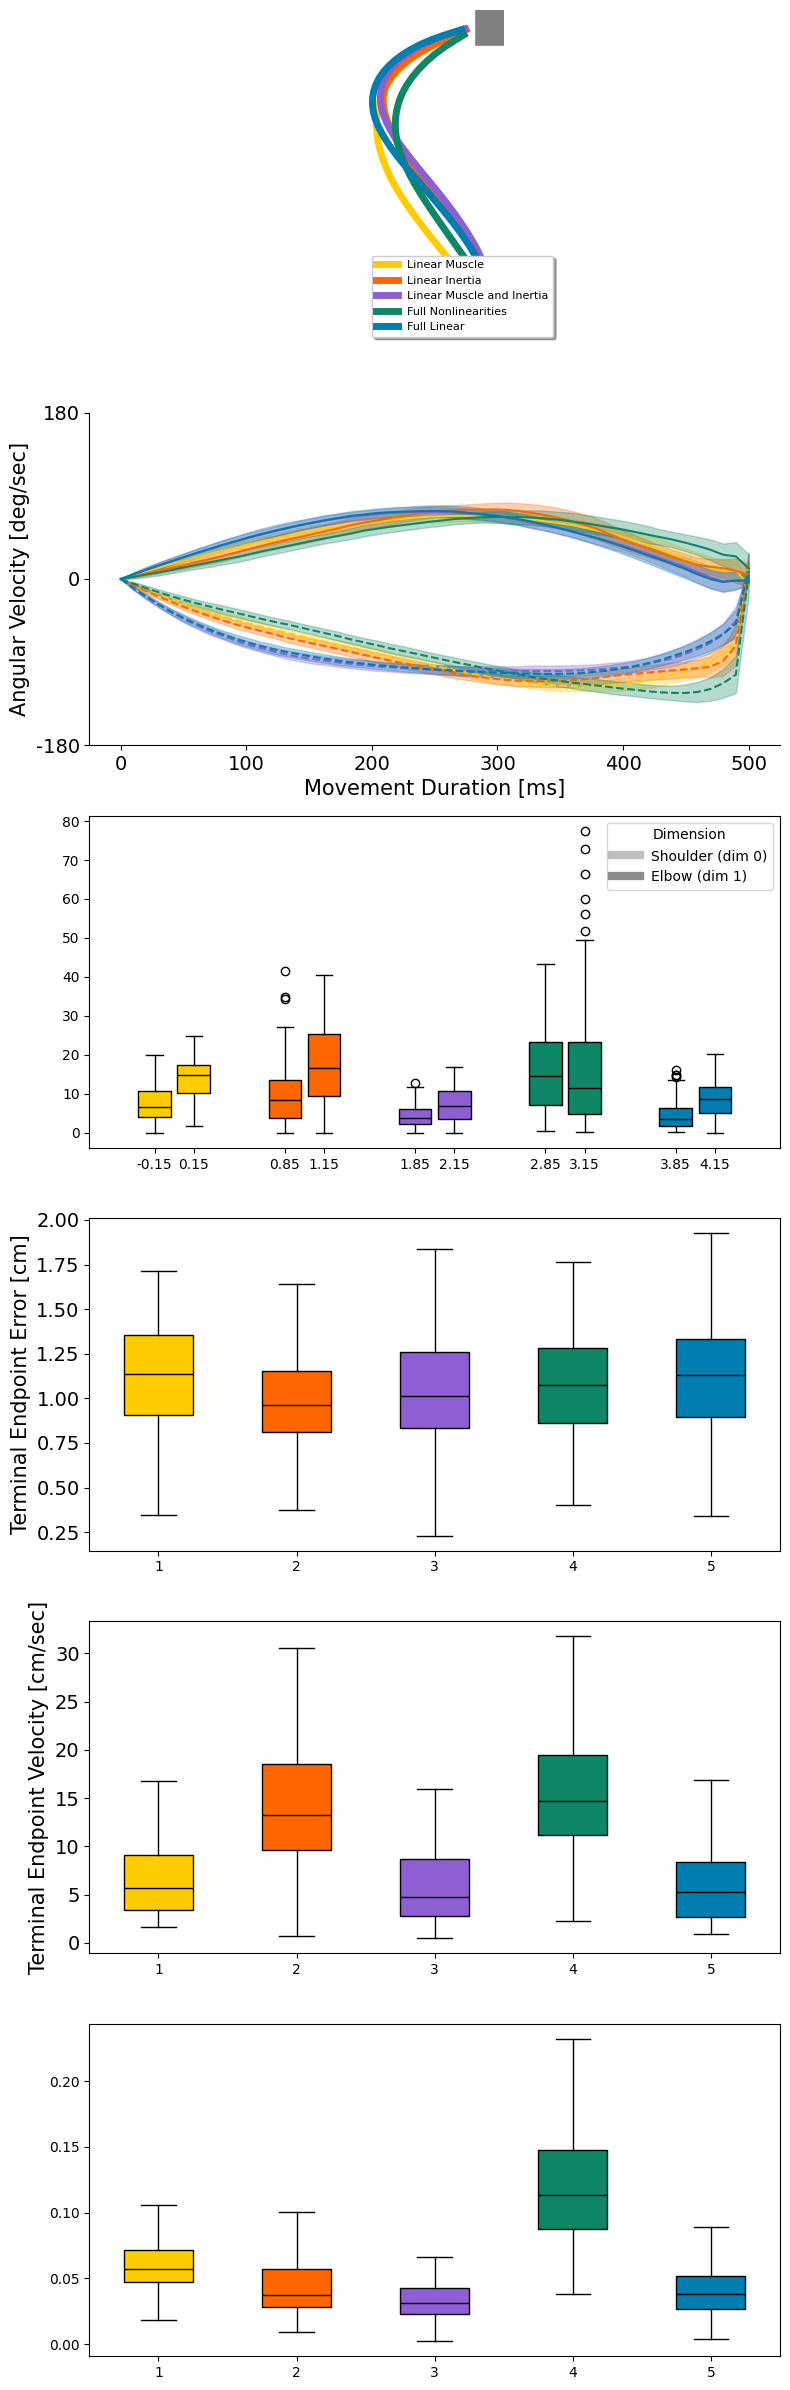

In [ ]:
MovementTime = .5
NumIteration = 50
Time = np.linspace(0,MovementTime*1000,NumIteration)
NUM_SIM = 100
FFPOW = 4e-4
Traj = np.zeros((5,NUM_SIM,NumIteration,2))

st = [0,50]
tg = [0,60]

def Compute_Cartesian_Speed(x):
    L1,L2 = 30,33
    ts,te,os,oe = x[0],x[1],x[2],x[3]
    Velx = -L1*np.sin(ts)*os - L2*np.sin(ts+te)*(os+oe)
    Vely = L1*np.cos(ts)*os + L2*np.cos(ts+te)*(os+oe)
    return np.sqrt(Velx**2 + Vely**2)

Cartesian_Speed = np.zeros((NUM_SIM,5,NumIteration))
Angular_Speed = np.zeros((NUM_SIM,5,2,NumIteration))
Cartesian_Vel = np.zeros((NUM_SIM,5,NumIteration))
Cost = np.zeros((NUM_SIM,5))
Trajectories = np.zeros((NUM_SIM,5,2,NumIteration))
for side in ["Left"]:
    fig,ax = plt.subplots(6,figsize = (8,24))
    for i in range(NUM_SIM):
        
        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": False, "nonlinear_inertia": True, "nonlinear_coriolis": True})
        Traj[0,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,0] = zilqg[:,2:4].T
        Trajectories[i,0] = xILQG,yILQG
        Cartesian_Vel[i,0] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,0] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": True, "nonlinear_inertia": False, "nonlinear_coriolis": True})
        Traj[1,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,1] = zilqg[:,2:4].T
        Trajectories[i,1] = xILQG,yILQG
        Cartesian_Vel[i,1] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,1] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": False, "nonlinear_inertia": False, "nonlinear_coriolis": True})
        Traj[2,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,2] = zilqg[:,2:4].T
        Trajectories[i,2] = xILQG,yILQG
        Cartesian_Vel[i,2] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,2] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": True, "nonlinear_inertia": True, "nonlinear_coriolis": True})
        Traj[3,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,3] = zilqg[:,2:4].T
        Trajectories[i,3] = xILQG,yILQG
        Cartesian_Vel[i,3] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,3] = Cost_function(zilqg,uILQG,tg = tg)

        xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  True,ff_power=FFPOW, FFside = side, args = {"nonlinear_muscle": False, "nonlinear_inertia": False, "nonlinear_coriolis": False})
        Traj[4,i] = np.array([xILQG,yILQG]).T
        Angular_Speed[i,4] = zilqg[:,2:4].T
        Trajectories[i,4] = xILQG,yILQG
        Cartesian_Vel[i,4] = Compute_Cartesian_Speed(zilqg.T)
        Cost[i,4] = Cost_function(zilqg,uILQG,tg = tg)
        


    
    Mean_traj = np.mean(Traj,axis = 1)
    colors = ["#FFCC00","#FF6600","#8D5FD3","#0D8766","#007EAF"]
    ax[0].plot(Mean_traj[0,:,0],Mean_traj[0,:,1], color=colors[0], linewidth=5,linestyle = "-",label = "Linear Muscle")
    ax[0].plot(Mean_traj[1,:,0],Mean_traj[1,:,1], color=colors[1], linewidth=5,linestyle = "-",label = "Linear Inertia" )
    ax[0].plot(Mean_traj[2,:,0],Mean_traj[2,:,1], color=colors[2], linewidth=5,linestyle = "-",label = "Linear Muscle and Inertia" )
    ax[0].plot(Mean_traj[3,:,0],Mean_traj[3,:,1], color=colors[3], linewidth=5,linestyle = "-",label = "Full Nonlinearities" )
    ax[0].plot(Mean_traj[4,:,0],Mean_traj[4,:,1], color=colors[4], linewidth=5,linestyle = "-",label = "Full Linear")
    





    ax[0].set_aspect("equal")
    ax[0].set_yticks([])
    ax[0].set_xticks([])

    delete_axis(ax[0])

    ax[0].plot([0],[tg[1]],marker = "s",markersize = 30,markerfacecolor='grey',zorder = 0,markeredgecolor = "white")

    ax[0].legend(fontsize=8,
            frameon=True,
            shadow=True,
            fancybox=True,
            loc="lower left")

    for i in range(5):
        mean_vel = np.mean(Angular_Speed[:,i,0],axis = 0)*180/pi
        std_vel = np.std(Angular_Speed[:,i,0],axis = 0)*180/pi
        # Pot mean line
        ax[1].plot(Time, mean_vel, color=colors[i])
        # Pot standard deviation band
        ax[1].fill_between(Time, mean_vel - std_vel, mean_vel + std_vel, color=colors[i], alpha=0.3)
        mean_vel = np.mean(Angular_Speed[:,i,1],axis = 0)*180/pi
        std_vel = np.std(Angular_Speed[:,i,1],axis = 0)*180/pi
        # Pot mean line
        ax[1].plot(Time, mean_vel, color=colors[i],linestyle = "--")
        #ax[2,i].set_ylim(-4,3)
        # Pot standard deviation band
        ax[1].fill_between(Time, mean_vel - std_vel, mean_vel + std_vel, color=colors[i], alpha=0.3)
    delete_axis(ax[1],sides = ["top","right"])
    ax[1].set_xlabel("Movement Duration [ms]" , fontsize = 15)
    ax[1].set_xticks([0,100,200,300,400,500],labels = [0,100,200,300,400,500],fontsize = 14)
    ax[1].set_ylabel("Angular Velocity [deg/sec]" , fontsize = 15)
    ax[1].set_yticks([-180,0,180],labels = [-180,0,180],fontsize = 14)
        #ax[0,i].scatter(tg[0],tg[1],marker = "s",s = 500,color = "grey")
    #plt.savefig("Nonlinearities.svg",dpi = 300)
    Final_Angular_Speed = np.abs(Angular_Speed[:,:,:,-1]*180/np.pi)

    # Plot boxplots side by side for the two dimensions
    positions1 = np.arange(5) - 0.15  # shift slightly left for dim 0
    positions2 = np.arange(5) + 0.15  # shift slightly right for dim 1
    for i in range(5):
        # Shoulder (dim 0)
        ax[2].boxplot(Final_Angular_Speed[:, i, 0],
                    positions=[positions1[i]],
                    widths=0.25,
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[i]),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"))

        # Elbow (dim 1)
        ax[2].boxplot(Final_Angular_Speed[:, i, 1],
                    positions=[positions2[i]],
                    widths=0.25,
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[i]),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"))

    # Formattin


    # Optional legend
    legend_handles = [
        plt.Line2D([0], [0], color='gray', lw=6, alpha=0.5, label='Shoulder (dim 0)'),
        plt.Line2D([0], [0], color='gray', lw=6, alpha=0.9, label='Elbow (dim 1)')
    ]
    ax[2].legend(handles=legend_handles, title='Dimension', loc='upper right')
    ax[3].set_xticks([])
    ax[3].tick_params(axis='y', labelsize=14)
    ax[3].set_ylabel("Terminal Endpoint Error [cm]",fontsize = 15)

    ax[4].set_xticks([])
    ax[4].tick_params(axis='y', labelsize=14)
    ax[4].set_ylabel("Terminal Endpoint Velocity [cm/sec]",fontsize = 15)
    TerminalEndPointVel = np.copy(Cartesian_Vel[:,:, -1])
    TerminalEndPoint = np.sqrt((Trajectories[:,:,0,-1])**2+(Trajectories[:,:,1,-1]-60)**2)

    box2 = ax[3].boxplot(TerminalEndPoint, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)

    box3 = ax[4].boxplot(TerminalEndPointVel, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)

    box4 = ax[5].boxplot(Cost, patch_artist=True,
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),showfliers=False)
    
    for box in [box2,box3,box4]:
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)

    plt.tight_layout()

    #plt.savefig("Abs.svg",dpi = 300)
    plt.show()